# 📈 Stock Market Analysis & Price Prediction using LSTM Deep Learning

**Author:** Roumyajit Sarkar  
**Domain:** Finance / Time Series  
**Level:** Advanced (Deep Learning)

## Objective
Predict future stock prices using LSTM (Long Short-Term Memory) neural networks on historical market data.

## Key Techniques
- Time Series Analysis & Feature Engineering
- Technical Indicators (RSI, MACD, Bollinger Bands)
- LSTM Neural Network with Keras
- Model Evaluation & Visualization

In [1]:
# Install required libraries
# !pip install yfinance pandas numpy matplotlib seaborn scikit-learn tensorflow keras plotly

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Stock Data
import yfinance as yf

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📥 Step 1: Data Collection

In [2]:
# Download stock data for multiple companies
tickers = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']
start_date = '2018-01-01'
end_date = '2024-01-01'

# Download AAPL as primary stock
df = yf.download('AAPL', start=start_date, end=end_date)
df.reset_index(inplace=True)

print(f'Dataset Shape: {df.shape}')
print(f'Date Range: {df["Date"].min()} to {df["Date"].max()}')
print('\nFirst 5 rows:')
df.head()

[*********************100%***********************]  1 of 1 completed

Dataset Shape: (1509, 6)
Date Range: 2018-01-02 00:00:00 to 2023-12-29 00:00:00

First 5 rows:


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2018-01-02,40.304173,40.313533,39.602254,39.812832,102223600
1,2018-01-03,40.297153,40.839972,40.233983,40.367346,118071600
2,2018-01-04,40.484333,40.587282,40.262059,40.369685,89738400
3,2018-01-05,40.945267,41.031836,40.489020,40.580269,94640000
4,2018-01-08,40.793171,41.087975,40.694899,40.793171,82271200


## 🔍 Step 2: Exploratory Data Analysis

In [3]:
# Basic Info
print('=== Dataset Info ===')
print(df.info())
print('\n=== Statistical Summary ===')
print(df.describe())
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1509 non-null   datetime64[ns]
 1   (Close, AAPL)   1509 non-null   float64       
 2   (High, AAPL)    1509 non-null   float64       
 3   (Low, AAPL)     1509 non-null   float64       
 4   (Open, AAPL)    1509 non-null   float64       
 5   (Volume, AAPL)  1509 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 70.9 KB
None

=== Statistical Summary ===
Price                            Date        Close         High          Low  \
Ticker                                        AAPL         AAPL         AAPL   
count                            1509  1509.000000  1509.000000  1509.000000   
mean    2020-12-30 14:13:07.276342016   107.723608   108.850195   106.484612   
min               2018-01-02 00:0

In [4]:
# Interactive Candlestick Chart
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=('AAPL Stock Price (Candlestick)', 'Volume'),
                    row_heights=[0.7, 0.3])

fig.add_trace(go.Candlestick(
    x=df['Date'], open=df['Open'], high=df['High'],
    low=df['Low'], close=df['Close'], name='AAPL'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=df['Date'], y=df['Volume'], name='Volume',
    marker_color='rgba(0,150,255,0.5)'
), row=2, col=1)

fig.update_layout(title='Apple Inc. (AAPL) Stock Analysis', height=700,
                  xaxis_rangeslider_visible=False)
fig.show()

## ⚙️ Step 3: Technical Indicators (Feature Engineering)

In [5]:
def add_technical_indicators(df):
    # Moving Averages
    df['MA_20'] = df['Close'].rolling(window=20).mean()
    df['MA_50'] = df['Close'].rolling(window=50).mean()
    df['MA_200'] = df['Close'].rolling(window=200).mean()

    # Bollinger Bands
    df['BB_middle'] = df['Close'].rolling(window=20).mean()
    df['BB_std'] = df['Close'].rolling(window=20).std()
    df['BB_upper'] = df['BB_middle'] + 2 * df['BB_std']
    df['BB_lower'] = df['BB_middle'] - 2 * df['BB_std']

    # RSI (Relative Strength Index)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # MACD
    exp1 = df['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp1 - exp2
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_histogram'] = df['MACD'] - df['MACD_signal']

    # Daily Returns & Volatility
    df['Daily_Return'] = df['Close'].pct_change()
    df['Volatility'] = df['Daily_Return'].rolling(window=20).std()

    return df

df = add_technical_indicators(df)
df.dropna(inplace=True)
print(f'Features added! Dataset shape: {df.shape}')
print('Columns:', list(df.columns))

Features added! Dataset shape: (1310, 19)
Columns: [('Date', ''), ('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL'), ('MA_20', ''), ('MA_50', ''), ('MA_200', ''), ('BB_middle', ''), ('BB_std', ''), ('BB_upper', ''), ('BB_lower', ''), ('RSI', ''), ('MACD', ''), ('MACD_signal', ''), ('MACD_histogram', ''), ('Daily_Return', ''), ('Volatility', '')]


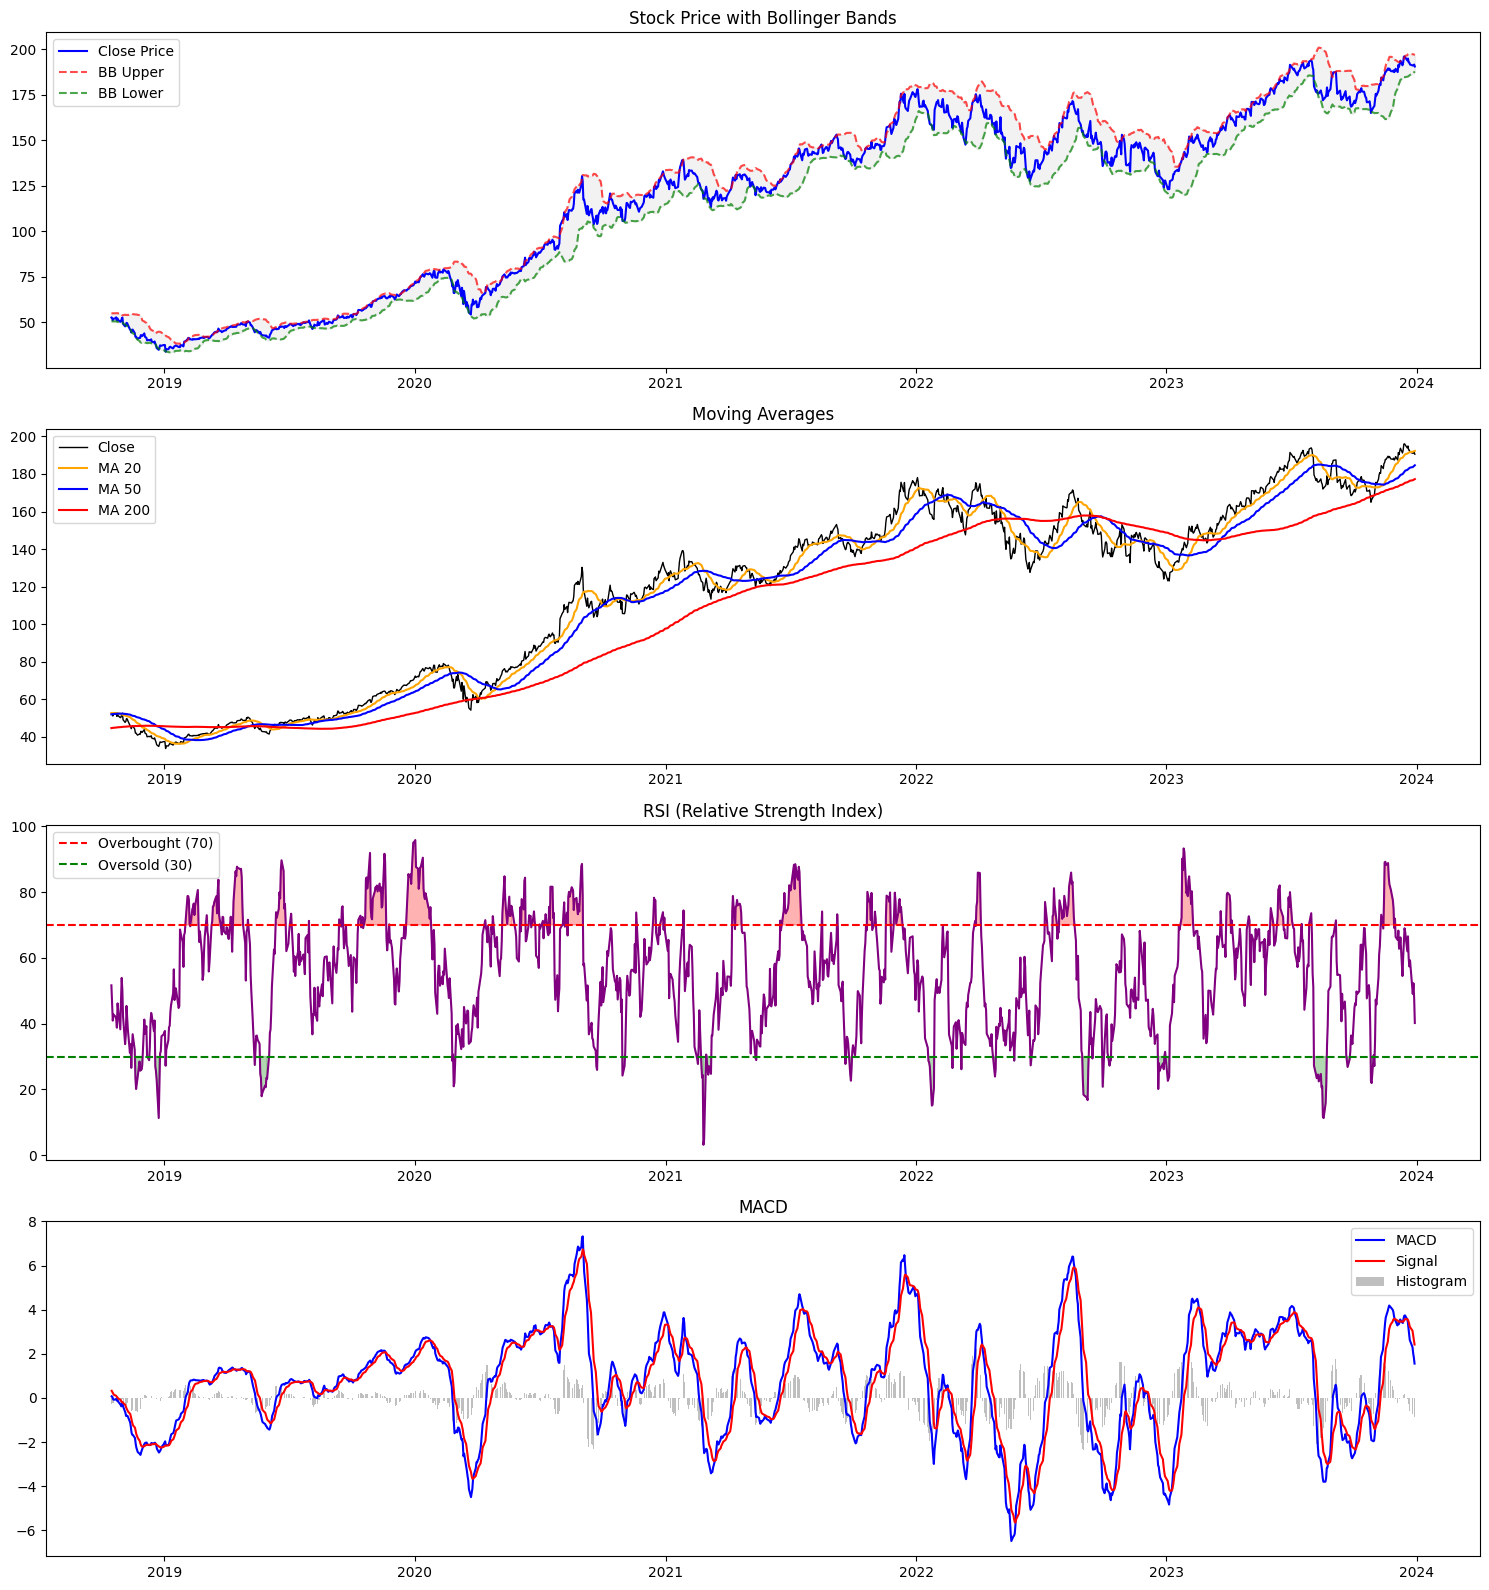

In [6]:
# Visualize Technical Indicators
fig, axes = plt.subplots(4, 1, figsize=(15, 16))

# Price + Bollinger Bands
axes[0].plot(df['Date'], df['Close'], label='Close Price', color='blue', linewidth=1.5)
axes[0].plot(df['Date'], df['BB_upper'], label='BB Upper', color='red', alpha=0.7, linestyle='--')
axes[0].plot(df['Date'], df['BB_lower'], label='BB Lower', color='green', alpha=0.7, linestyle='--')
axes[0].fill_between(df['Date'], df['BB_upper'], df['BB_lower'], alpha=0.1, color='gray')
axes[0].set_title('Stock Price with Bollinger Bands')
axes[0].legend()

# Moving Averages
axes[1].plot(df['Date'], df['Close'], label='Close', color='black', linewidth=1)
axes[1].plot(df['Date'], df['MA_20'], label='MA 20', color='orange')
axes[1].plot(df['Date'], df['MA_50'], label='MA 50', color='blue')
axes[1].plot(df['Date'], df['MA_200'], label='MA 200', color='red')
axes[1].set_title('Moving Averages')
axes[1].legend()

# RSI
axes[2].plot(df['Date'], df['RSI'], color='purple', linewidth=1.5)
axes[2].axhline(y=70, color='red', linestyle='--', label='Overbought (70)')
axes[2].axhline(y=30, color='green', linestyle='--', label='Oversold (30)')
axes[2].fill_between(df['Date'], 70, df['RSI'], where=(df['RSI'] >= 70), alpha=0.3, color='red')
axes[2].fill_between(df['Date'], 30, df['RSI'], where=(df['RSI'] <= 30), alpha=0.3, color='green')
axes[2].set_title('RSI (Relative Strength Index)')
axes[2].legend()

# MACD
axes[3].plot(df['Date'], df['MACD'], label='MACD', color='blue')
axes[3].plot(df['Date'], df['MACD_signal'], label='Signal', color='red')
axes[3].bar(df['Date'], df['MACD_histogram'], label='Histogram', color='gray', alpha=0.5)
axes[3].set_title('MACD')
axes[3].legend()

plt.tight_layout()
plt.savefig('technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤖 Step 4: LSTM Model Building

In [7]:
# Prepare data for LSTM
features = ['Close', 'Volume', 'MA_20', 'MA_50', 'RSI', 'MACD', 'Volatility', 'BB_upper', 'BB_lower']
target = 'Close'

data = df[features].values

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 0])  # Close price is index 0
    return np.array(X), np.array(y)

SEQ_LENGTH = 60
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Train/Test split (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f'Training samples: {X_train.shape}')
print(f'Test samples: {X_test.shape}')

Training samples: (1000, 60, 9)
Test samples: (250, 60, 9)


In [8]:
# Build LSTM Model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LENGTH, len(features))),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,793 (522.63 KB)

 Trainable params: 133,409 (521.13 KB)

 Non-trainable params: 384 (1.50 KB)

In [9]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7)

# Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print('\n✅ Model training complete!')

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step - loss: 0.0537 - mae: 0.1757 - val_loss: 0.0928 - val_mae: 0.2972 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - loss: 0.0223 - mae: 0.1181 - val_loss: 0.0600 - val_mae: 0.2370 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - loss: 0.0175 - mae: 0.1045 - val_loss: 0.0502 - val_mae: 0.2163 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - loss: 0.0129 - mae: 0.0896 - val_loss: 0.0578 - val_mae: 0.2323 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - loss: 0.0098 - mae: 0.0769 - val_loss: 0.0304 - val_mae: 0.1648 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - loss: 0.0094 - mae: 0.0766 - val_loss: 0.0232 - val_mae: 0.1418 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - loss: 0.0082 - mae: 0.0710 - val_loss: 0.0155 - val_mae: 0.1149 - learning_rate: 0.00

## 📊 Step 5: Evaluation & Results

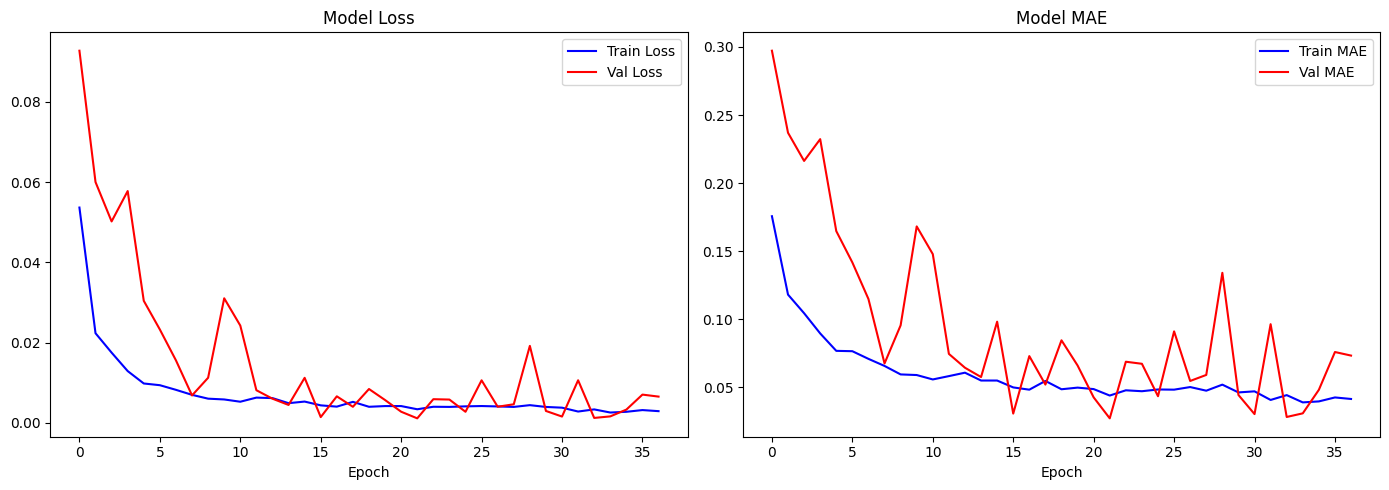

In [10]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='red')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE', color='blue')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='red')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Predictions
y_pred_scaled = model.predict(X_test)

# Inverse transform
dummy = np.zeros((len(y_pred_scaled), len(features)))
dummy[:, 0] = y_pred_scaled.flatten()
y_pred = scaler.inverse_transform(dummy)[:, 0]

dummy2 = np.zeros((len(y_test), len(features)))
dummy2[:, 0] = y_test
y_actual = scaler.inverse_transform(dummy2)[:, 0]

# Metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print('=== Model Performance ===')
print(f'RMSE  : ${rmse:.2f}')
print(f'MAE   : ${mae:.2f}')
print(f'R²    : {r2:.4f}')
print(f'MAPE  : {mape:.2f}%')

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step
=== Model Performance ===
RMSE  : $14.69
MAE   : $12.56
R²    : 0.2780
MAPE  : 7.05%


In [12]:
# Actual vs Predicted Plot
fig = go.Figure()
fig.add_trace(go.Scatter(y=y_actual, mode='lines', name='Actual Price', line=dict(color='blue')))
fig.add_trace(go.Scatter(y=y_pred, mode='lines', name='Predicted Price', line=dict(color='red', dash='dash')))
fig.update_layout(
    title='AAPL Stock Price: Actual vs Predicted (LSTM)',
    xaxis_title='Time Steps',
    yaxis_title='Price (USD)',
    height=500
)
fig.show()
print('\n✅ Stock Market Analysis Complete!')


✅ Stock Market Analysis Complete!
